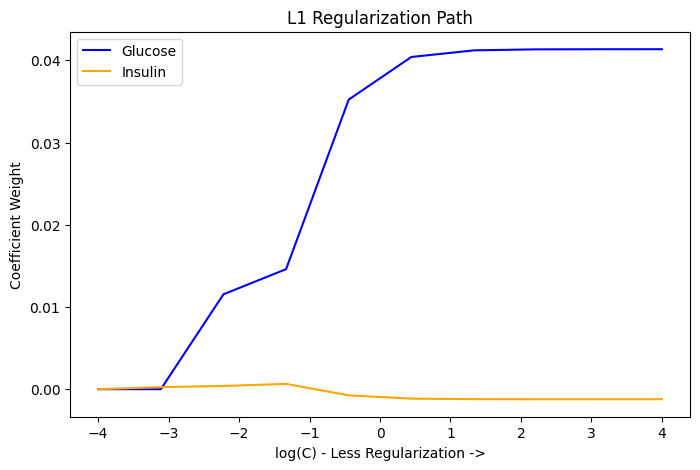

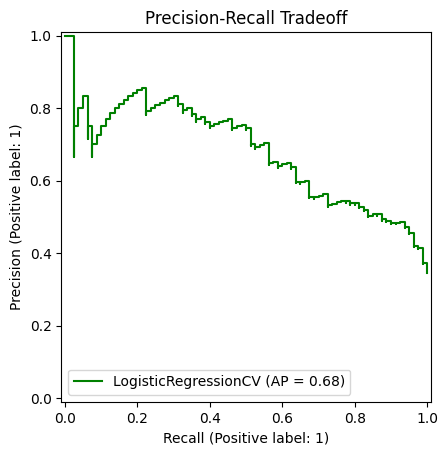

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import PrecisionRecallDisplay

data = pd.read_csv('/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv')

data['Glucose'] = data['Glucose'].replace(0, data['Glucose'].mean())
data['BMI'] = data['BMI'].replace(0, data['BMI'].mean())

X = data.drop('Outcome', axis=1)
y = data['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Cs = np.logspace(-4, 4, 10)
coefs_insulin = []
coefs_glucose = []

for c in Cs:
    model_path = LogisticRegressionCV(Cs=[c], penalty='l1', solver='liblinear', cv=2)
    model_path.fit(X_train, y_train)
    coef_dict = dict(zip(X.columns, model_path.coef_[0]))
    coefs_insulin.append(coef_dict.get('Insulin', 0))
    coefs_glucose.append(coef_dict.get('Glucose', 0))

plt.figure(figsize=(8, 5))
plt.plot(np.log10(Cs), coefs_glucose, label='Glucose', color='blue')
plt.plot(np.log10(Cs), coefs_insulin, label='Insulin', color='orange')
plt.xlabel('log(C) - Less Regularization ->')
plt.ylabel('Coefficient Weight')
plt.title('L1 Regularization Path')
plt.legend()
plt.show()

final_model = LogisticRegressionCV(Cs=10, penalty='l1', solver='liblinear', cv=2)
final_model.fit(X_train, y_train)

display = PrecisionRecallDisplay.from_estimator(final_model, X_test, y_test, color='green')
display.ax_.set_title("Precision-Recall Tradeoff")
plt.show()